# Exploratory Data Analysis (EDA)

## Mô tả
Notebook này thực hiện phân tích dữ liệu khám phá cho tập dữ liệu UIT-VSFC.

**Nội dung:**
- Phân tích phân phối nhãn (label distribution)
- Thống kê văn bản (text statistics)
- Phân tích tần suất từ (word frequency)
- Phân tích mất cân bằng lớp (class imbalance)
- Phân tích độ phủ từ vựng VietSentiWordNet

**Mục đích:** Hiểu rõ đặc điểm dữ liệu trước khi xây dựng các mô hình phân loại.

## 1. Setup và Import Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install matplotlib seaborn pandas numpy

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Pandas version: 2.2.2
NumPy version: 2.0.2


In [4]:
def set_seed(seed=42):
    np.random.seed(seed)

set_seed(42)

## 2. Configuration

In [5]:
class Config:
    BASE_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis'
    DATA_DIR = f'{BASE_DIR}/data/processed'
    RAW_DATA_DIR = f'{BASE_DIR}/data/raw'
    MODEL_TYPE = 'EDA'
    EXPERIMENT_TYPE = 'baseline'
    RESULTS_DIR = f'{BASE_DIR}/results/{MODEL_TYPE}/{EXPERIMENT_TYPE}'
    NUM_CLASSES = 3
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    SENTIWORDNET_FILE = f'{BASE_DIR}/data/sentiwordnet-dataset/VietSentiWordnet_Ver1.3.5.txt'
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')

config = Config()
for dir_path in [config.RESULTS_DIR, config.SUMMARIES_DIR, config.VISUALIZATIONS_DIR]:
    os.makedirs(dir_path, exist_ok=True)
print(f'Results will be saved to: {config.RESULTS_DIR}')
print(f'Structure: summaries/, visualizations/')


Results will be saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/EDA/baseline
Structure: summaries/, visualizations/


## 3. Data Loading Functions

In [6]:
# Import from centralized data_utils module
import sys
sys.path.append(config.BASE_DIR)
from src.data_utils import load_data

train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

In [7]:
# Import from centralized data_utils module
from src.data_utils import load_sentiwordnet

word_to_scores = load_sentiwordnet(config.SENTIWORDNET_FILE)

In [8]:
# Import from centralized data_utils module
from src.data_utils import preprocess_vietnamese

sample_text = "Hoc tap rat tot! Nhung thi kho qua."
print(f'Original: {sample_text}')
print(f'Preprocessed: {preprocess_vietnamese(sample_text)}')

Original: Hoc tap rat tot! Nhung thi kho qua.
Preprocessed: học tap rat tot nhưng thi khó qua


## 4. Visualizations

Lưu tất cả biểu đồ vào `results/EDA/baseline/visualizations/`.

**Danh sách biểu đồ:**
1. `label_distribution.png` — Phân phối nhãn theo split
2. `text_length_distribution.png` — Phân phối độ dài văn bản
3. `class_imbalance.png` — Mất cân bằng lớp (stacked bar + pie)
4. `word_frequency_by_class.png` — Top 15 từ theo từng lớp
5. `sentiwordnet_coverage.png` — Độ phủ từ VietSentiWordNet


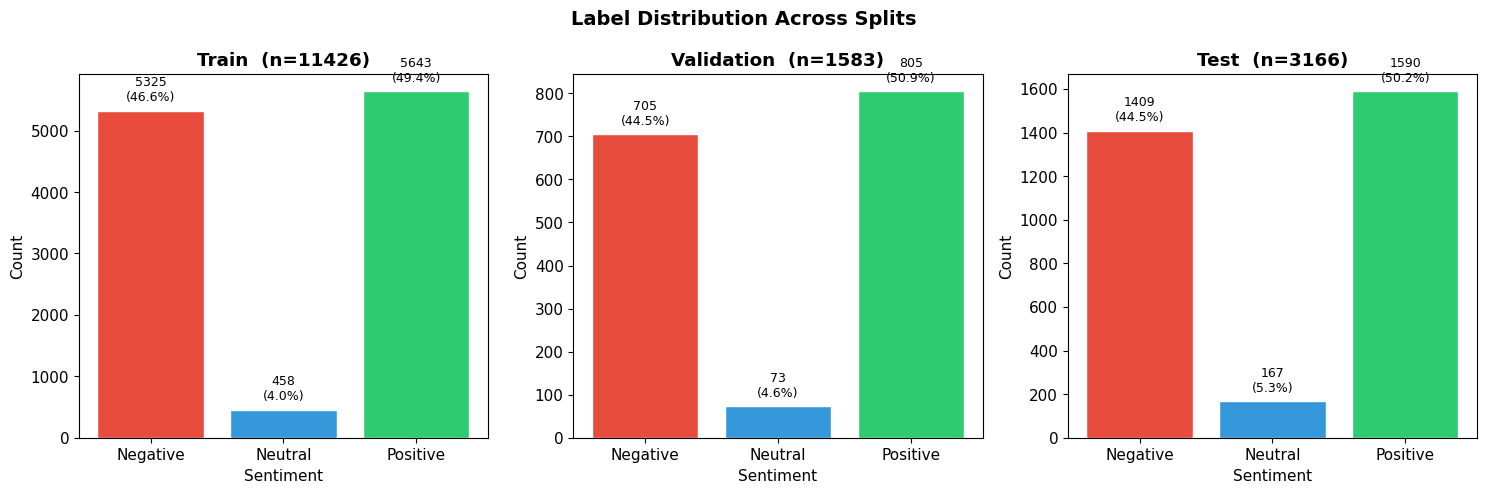

Saved: label_distribution.png


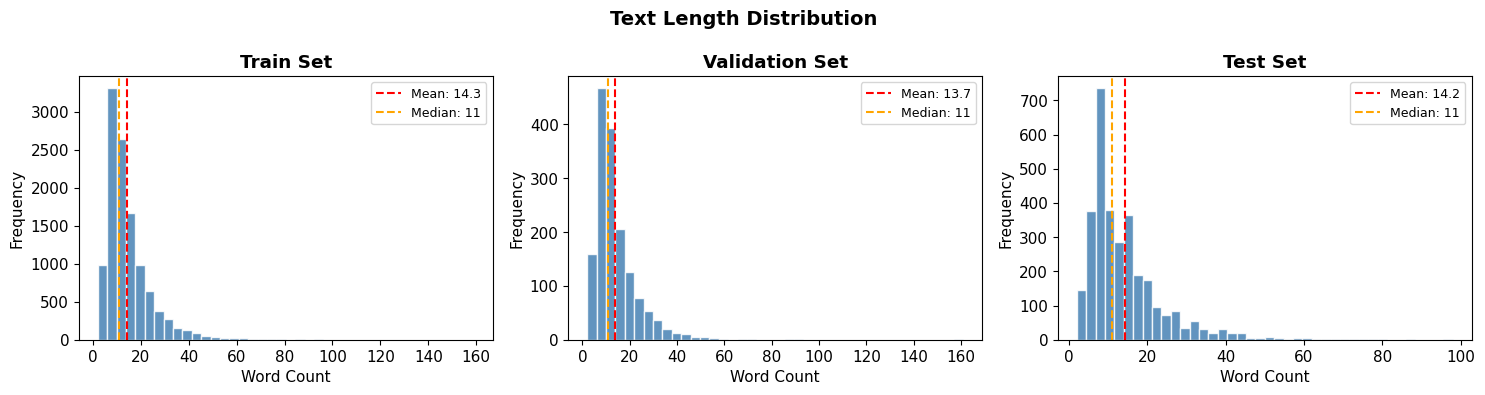

Saved: text_length_distribution.png


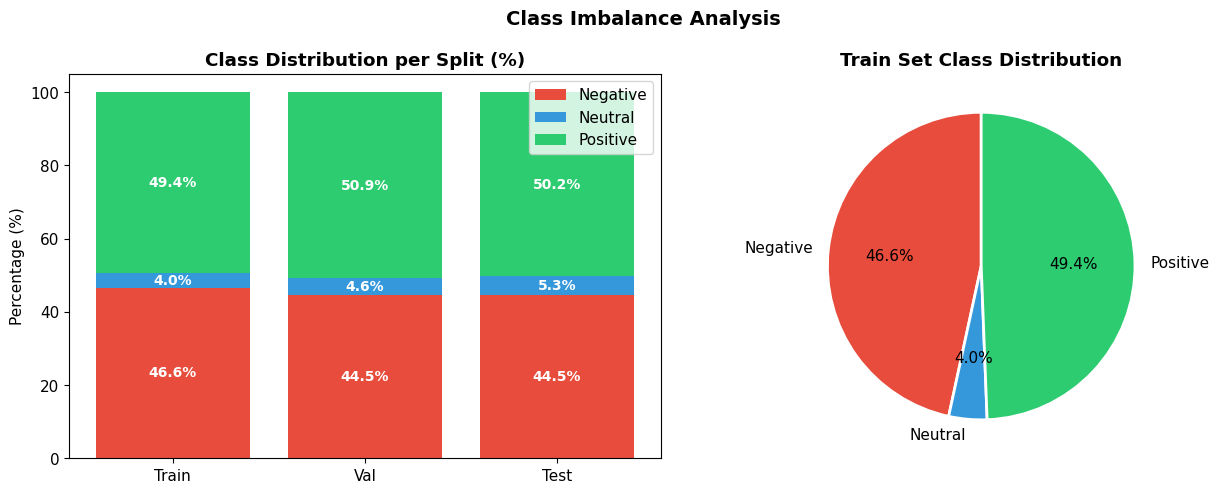

Saved: class_imbalance.png


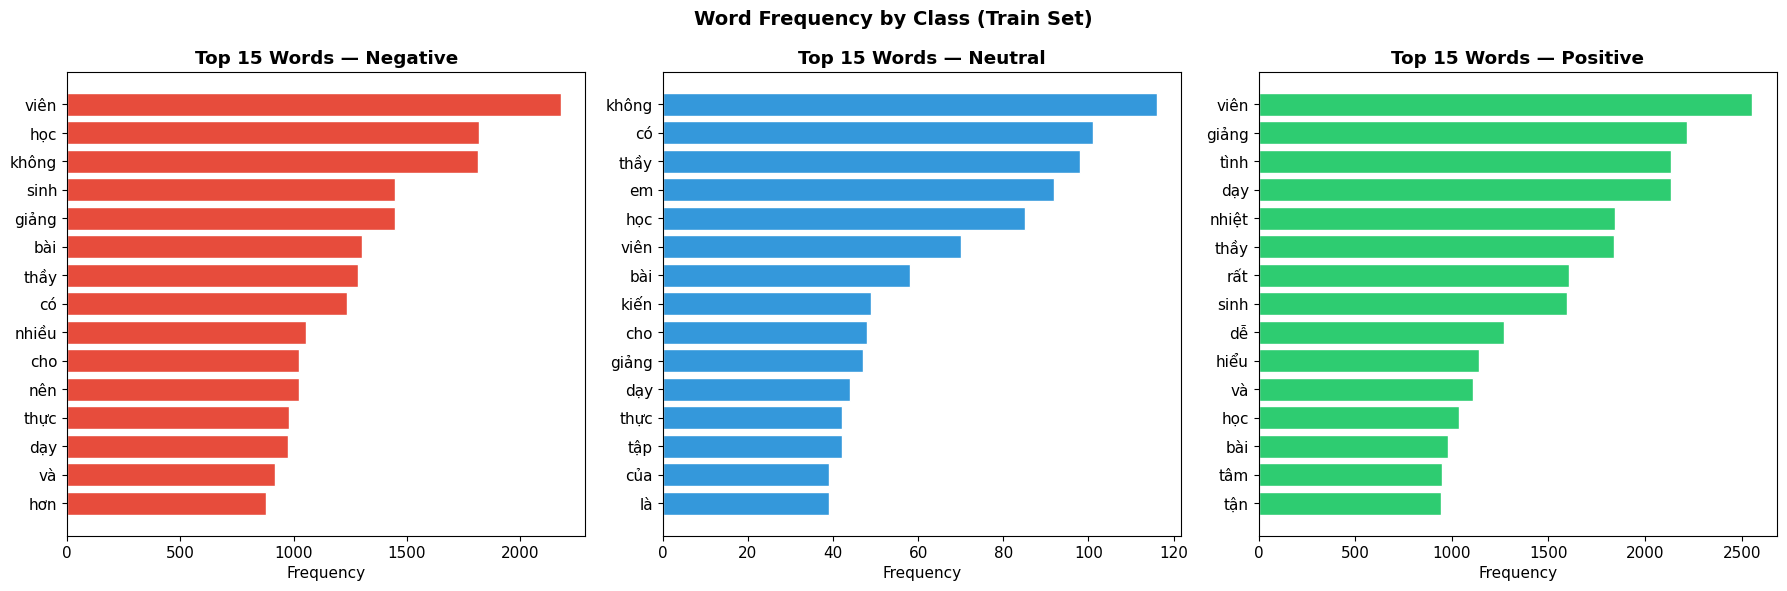

Saved: word_frequency_by_class.png


In [9]:

os.makedirs(config.VISUALIZATIONS_DIR, exist_ok=True)
COLORS = ['#e74c3c', '#3498db', '#2ecc71']
plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white'})

# ── 1. Label Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, labels) in zip(axes, [('Train', train_labels),
                                       ('Validation', val_labels),
                                       ('Test', test_labels)]):
    counts     = Counter(labels)
    cls_names  = [config.LABEL_MAP[i] for i in range(config.NUM_CLASSES)]
    cls_counts = [counts.get(i, 0) for i in range(config.NUM_CLASSES)]
    bars = ax.bar(cls_names, cls_counts, color=COLORS, edgecolor='white')
    for bar, cnt in zip(bars, cls_counts):
        pct = cnt / len(labels) * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(cls_counts) * 0.02,
                f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{name}  (n={len(labels)})', fontweight='bold')
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Count')
plt.suptitle('Label Distribution Across Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'label_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: label_distribution.png')

# ── 2. Text Length Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, texts) in zip(axes, [('Train', train_texts),
                                      ('Validation', val_texts),
                                      ('Test', test_texts)]):
    lengths = [len(t.split()) for t in texts]
    ax.hist(lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(lengths), color='red', linestyle='--',
               label=f'Mean: {np.mean(lengths):.1f}')
    ax.axvline(np.median(lengths), color='orange', linestyle='--',
               label=f'Median: {np.median(lengths):.0f}')
    ax.set_title(f'{name} Set', fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
plt.suptitle('Text Length Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'text_length_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: text_length_distribution.png')

# ── 3. Class Imbalance (stacked bar + pie) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
split_dicts = {'Train': Counter(train_labels),
               'Val':   Counter(val_labels),
               'Test':  Counter(test_labels)}
x_labels = list(split_dicts.keys())
totals   = [sum(v.values()) for v in split_dicts.values()]
bottoms  = np.zeros(len(x_labels))
for cls_idx, cls_name in config.LABEL_MAP.items():
    pcts = [split_dicts[s].get(cls_idx, 0) / t * 100
            for s, t in zip(x_labels, totals)]
    axes[0].bar(x_labels, pcts, bottom=bottoms,
                label=cls_name, color=COLORS[cls_idx])
    for i, (p, b) in enumerate(zip(pcts, bottoms)):
        if p > 3:
            axes[0].text(i, b + p/2, f'{p:.1f}%', ha='center', va='center',
                         color='white', fontweight='bold', fontsize=10)
    bottoms += np.array(pcts)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Class Distribution per Split (%)', fontweight='bold')
axes[0].legend(loc='upper right')
train_vals = [Counter(train_labels).get(i, 0) for i in range(config.NUM_CLASSES)]
axes[1].pie(train_vals,
            labels=[config.LABEL_MAP[i] for i in range(config.NUM_CLASSES)],
            autopct='%1.1f%%', colors=COLORS, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Train Set Class Distribution', fontweight='bold')
plt.suptitle('Class Imbalance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'class_imbalance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_imbalance.png')

# ── 4. Top-15 Words per Class ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
processed = [preprocess_vietnamese(t) for t in train_texts]
for cls_idx, ax in enumerate(axes):
    cls_texts = [processed[i] for i in range(len(processed))
                 if train_labels[i] == cls_idx]
    freq = Counter(' '.join(cls_texts).split()).most_common(15)
    words, cnts = zip(*freq)
    ax.barh(list(reversed(words)), list(reversed(cnts)),
            color=COLORS[cls_idx], edgecolor='white')
    ax.set_title(f'Top 15 Words — {config.LABEL_MAP[cls_idx]}', fontweight='bold')
    ax.set_xlabel('Frequency')
plt.suptitle('Word Frequency by Class (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'word_frequency_by_class.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: word_frequency_by_class.png')


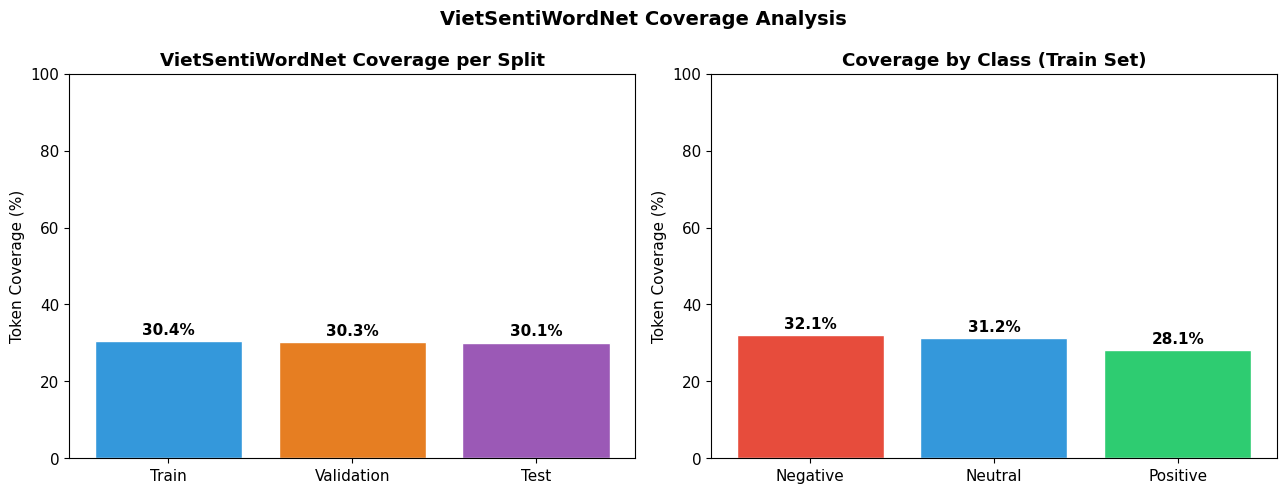

Saved: sentiwordnet_coverage.png

✓ All EDA visualizations saved to:
  /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/EDA/baseline/visualizations


In [10]:

# ── SentiWordNet Coverage Analysis ───────────────────────────────────────────
def compute_coverage(texts):
    covered = total = 0
    for text in texts:
        for w in preprocess_vietnamese(text).split():
            total += 1
            if w in word_to_scores:
                covered += 1
    return (covered / total * 100) if total else 0

COLORS = ['#e74c3c', '#3498db', '#2ecc71']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

split_info = [('Train', train_texts), ('Validation', val_texts), ('Test', test_texts)]
split_names = [s for s, _ in split_info]
split_covs  = [compute_coverage(t) for _, t in split_info]
bars = axes[0].bar(split_names, split_covs,
                   color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='white')
axes[0].set_ylim(0, 100)
axes[0].set_title('VietSentiWordNet Coverage per Split', fontweight='bold')
axes[0].set_ylabel('Token Coverage (%)')
for bar, v in zip(bars, split_covs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

cls_covs = [
    compute_coverage([train_texts[i] for i in range(len(train_texts)) if train_labels[i] == c])
    for c in range(config.NUM_CLASSES)
]
bars2 = axes[1].bar([config.LABEL_MAP[i] for i in range(config.NUM_CLASSES)],
                    cls_covs, color=COLORS, edgecolor='white')
axes[1].set_ylim(0, 100)
axes[1].set_title('Coverage by Class (Train Set)', fontweight='bold')
axes[1].set_ylabel('Token Coverage (%)')
for bar, v in zip(bars2, cls_covs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('VietSentiWordNet Coverage Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'sentiwordnet_coverage.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentiwordnet_coverage.png')
print(f'\n✓ All EDA visualizations saved to:\n  {config.VISUALIZATIONS_DIR}')
